# Week 6, Day 2: Prediction Models — Match Winner & Top Player

Builds on the leakage-safe feature tables and `time_based_split` contract from
Day 1 (`AFL_Week6_Day1_Data_Foundations.ipynb`, holdout year 2024 onward).

Two models come out of today:

1. **Match winner**:  binary classifier, team-match grain, `win_flag` target.
2. **Top player**:  regression on `fantasy_points`, player-match grain, ranked
   within match to get a top-N list.

Both get wrapped as plain Python functions in `predict.py` at the end, ready
to be turned into LangChain/LangGraph tools on Day 4.


In [12]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LogisticRegression, Ridge
from sklearn.ensemble import HistGradientBoostingClassifier, HistGradientBoostingRegressor
from sklearn.metrics import (accuracy_score, f1_score, roc_auc_score, brier_score_loss,
                              mean_absolute_error, mean_squared_error)
from sklearn.calibration import calibration_curve
from sklearn.inspection import permutation_importance

pd.set_option('display.max_columns', 50)
plt.rcParams['figure.figsize'] = (7, 4.5)

team = pd.read_parquet('../Day-1/afl_team_match_features_v2.parquet')
player = pd.read_parquet('../Day-1/afl_player_match_features_v2.parquet')

print('team table:', team.shape)
print('player table:', player.shape)


team table: (15808, 37)
player table: (237193, 41)


## Setup: reconstructing the split and adding opponent context

One thing the Day 1 team-match table doesn't have: **opponent's own stats in
the same row**. Each row is one team's perspective (`team_winrate_last5` etc
belong to `team`, not `opponent`). A model trained on that alone can't
directly compare the two sides, it only sees one team's absolute numbers.

Fix: self-join the table to itself on `match_date` + `team` + `opponent` to
pull in the opponent's own rolling stats, then take **diffs** (`team` minus
`opponent`). This is the one addition on top of the Day 1 feature tables, and
it's the actual input the classifier trains on.


In [13]:
def time_based_split(df, date_col='match_date', holdout_start_year=2024):
    df = df.copy()
    yr = df[date_col].dt.year
    return df[yr < holdout_start_year], df[yr >= holdout_start_year]

own_cols = ['team','opponent','match_date','team_winrate_last3','team_winrate_last5','team_winrate_last10',
            'team_avgmargin_last3','team_avgmargin_last5','team_avgmargin_last10','team_streak_entering',
            'days_since_last_game','season_winrate_to_date','ladder_rank_to_date']

opp = team[own_cols].rename(columns={
    'team':'opponent', 'opponent':'team',
    'team_winrate_last3':'opp_winrate_last3','team_winrate_last5':'opp_winrate_last5','team_winrate_last10':'opp_winrate_last10',
    'team_avgmargin_last3':'opp_avgmargin_last3','team_avgmargin_last5':'opp_avgmargin_last5','team_avgmargin_last10':'opp_avgmargin_last10',
    'team_streak_entering':'opp_streak_entering','days_since_last_game':'opp_days_since_last_game',
    'season_winrate_to_date':'opp_season_winrate_to_date','ladder_rank_to_date':'opp_ladder_rank_to_date'
})

match = team.merge(opp, on=['team','opponent','match_date'], how='left', validate='one_to_one')
assert match['opp_winrate_last5'].isna().sum() == team['team_winrate_last5'].isna().sum(), 'self-join dropped or duplicated rows'

match['diff_winrate_last3'] = match['team_winrate_last3'] - match['opp_winrate_last3']
match['diff_winrate_last5'] = match['team_winrate_last5'] - match['opp_winrate_last5']
match['diff_winrate_last10'] = match['team_winrate_last10'] - match['opp_winrate_last10']
match['diff_avgmargin_last3'] = match['team_avgmargin_last3'] - match['opp_avgmargin_last3']
match['diff_avgmargin_last5'] = match['team_avgmargin_last5'] - match['opp_avgmargin_last5']
match['diff_avgmargin_last10'] = match['team_avgmargin_last10'] - match['opp_avgmargin_last10']
match['diff_streak'] = match['team_streak_entering'] - match['opp_streak_entering']
match['diff_season_winrate'] = match['season_winrate_to_date'] - match['opp_season_winrate_to_date']
match['diff_ladder_rank'] = match['opp_ladder_rank_to_date'] - match['ladder_rank_to_date']  # positive = this team ranked better
match['diff_rest_days'] = match['days_since_last_game'] - match['opp_days_since_last_game']

train, holdout = time_based_split(match, holdout_start_year=2024)
print(f'Train:   {train.shape[0]:>6} rows | {train.year.min()}-{train.year.max()}')
print(f'Holdout: {holdout.shape[0]:>6} rows | {holdout.year.min()}-{holdout.year.max()}')
print()
print(holdout['result'].value_counts())


Train:    14944 rows | 1983-2023
Holdout:    864 rows | 2024-2025

result
L    428
W    428
D      8
Name: count, dtype: int64


No rows were lost or duplicated in the self-join. Holdout is 2024 to 2025,
864 team-match rows, 432 actual matches. Draws are rare (8 of 864, about 0.9%
here vs 1.4% historically), consistent with the data dictionary.


## Task 1: Baseline Models

### Match winner baselines

Two baselines, per the brief:
- **Always predict home team wins.**
- **Always predict the higher-ladder team wins**, using `ladder_rank_to_date`
  (lower number = better). Falls back to the home-team pick when ranks are
  missing or tied (early season, before enough rounds exist).


In [14]:
pred_home = holdout['is_home'].values
acc_home = accuracy_score(holdout['win_flag'], pred_home)
f1_home = f1_score(holdout['win_flag'], pred_home)
auc_home = roc_auc_score(holdout['win_flag'], pred_home)

rank_diff = holdout['diff_ladder_rank']
pred_ladder = np.where(rank_diff.notna() & (rank_diff != 0), (rank_diff > 0).astype(int), holdout['is_home'].values)
acc_ladder = accuracy_score(holdout['win_flag'], pred_ladder)
f1_ladder = f1_score(holdout['win_flag'], pred_ladder)
auc_ladder = roc_auc_score(holdout['win_flag'], pred_ladder)

baseline_table = pd.DataFrame({
    'baseline': ['always home team wins', 'always higher-ladder team wins'],
    'accuracy': [acc_home, acc_ladder],
    'f1': [f1_home, f1_ladder],
    'roc_auc': [auc_home, auc_ladder]
}).round(4)
baseline_table


,baseline,accuracy,f1,roc_auc
0,always home team wins,0.5671,0.5651,0.5671
1,always higher-ladder team wins,0.6319,0.6302,0.6320


The ladder baseline (63.2% accuracy) clears the home-advantage baseline
(56.7%) by a wide margin. That's expected: home ground is worth something in
the AFL but knowing which team is actually good matters more. ROC AUC for
these baselines is computed on hard 0/1 predictions rather than a real
probability, so it's really just a rescaled accuracy here, not a genuine
ranking measure, that only becomes meaningful once a model outputs
probabilities in Task 2.

This ladder baseline (63.2%) is the number the real classifier in Task 2
has to clear, and it sits close to the bottom of the "realistic ceiling"
band (65 to 72% per the data dictionary), which is a useful sanity anchor.

### Top player baseline

The brief allows "last week's leader repeats" or "season-average leader".
The feature table only stores **rolling averages** (`last3`/`last5`), not a
single prior match's value, so the closest available proxy to "recent-form
leader" is `player_fantasy_last5`: predict each player will score their own
trailing 5-game average, and rank players within a match by that number.


In [15]:
player_ctx = team[['team','match_date','is_home','venue_state']].drop_duplicates()
player_m = player.merge(player_ctx, on=['team','match_date'], how='left')
assert player_m['is_home'].isna().sum() == 0

p_train, p_holdout = time_based_split(player_m, holdout_start_year=2024)
p_holdout = p_holdout.copy()
p_holdout['match_id'] = (p_holdout['match_date'].astype(str) + '_'
                          + p_holdout[['team','opponent']].min(axis=1) + '_'
                          + p_holdout[['team','opponent']].max(axis=1))

league_median = p_train['fantasy_points'].median()
baseline_pred = p_holdout['player_fantasy_last5'].fillna(league_median).values

def topk_hit_rate(df, pred_values, k=5):
    tmp = df.copy()
    tmp['_pred'] = pred_values
    hits = []
    for mid, g in tmp.groupby('match_id'):
        if len(g) < k:
            continue
        actual_top = g.loc[g['fantasy_points'].idxmax(), 'player_id']
        pred_top_k = set(g.nlargest(k, '_pred')['player_id'])
        hits.append(actual_top in pred_top_k)
    return float(np.mean(hits)), len(hits)

mae_b = mean_absolute_error(p_holdout['fantasy_points'], baseline_pred)
rmse_b = np.sqrt(mean_squared_error(p_holdout['fantasy_points'], baseline_pred))
hit_b, n_matches = topk_hit_rate(p_holdout, baseline_pred, k=5)

print(f'Baseline (recent-form leader, last-5 avg)')
print(f'  MAE            : {mae_b:.2f} fantasy points')
print(f'  RMSE           : {rmse_b:.2f} fantasy points')
print(f'  Top-5 hit rate : {hit_b:.3f}  (across {n_matches} holdout matches)')


Baseline (recent-form leader, last-5 avg)
  MAE            : 18.37 fantasy points
  RMSE           : 23.29 fantasy points
  Top-5 hit rate : 0.574  (across 432 holdout matches)


Top-5 hit rate here means: does the actual top scorer of the match appear
anywhere in the 5 players we'd have flagged as most likely to lead? A naive
"just use their recent average" already gets this right about 57% of the
time. Fantasy points are genuinely volatile week to week (this matches the
high coefficient-of-variation finding from the Day 1 consistency analysis),
so a good chunk of "who has the big game" is close to unpredictable noise.
This is the number Task 3 has to beat.


## Task 2: Match Winner Model

Preprocessing: median-impute and scale the numeric diff features (handles
the early-season NaNs from short rolling windows and missing ladder data),
one-hot encode `venue_state`. Two model types on the same preprocessing:
**Logistic Regression** (interpretable, linear) and **Gradient Boosting**
(`HistGradientBoostingClassifier`, captures nonlinearity/interactions,
handles NaN natively too).


In [16]:
MATCH_NUM = ['is_home','is_interstate_travel',
             'diff_winrate_last3','diff_winrate_last5','diff_winrate_last10',
             'diff_avgmargin_last3','diff_avgmargin_last5','diff_avgmargin_last10',
             'diff_streak','diff_season_winrate','diff_ladder_rank','diff_rest_days',
             'h2h_winrate_vs_opp','h2h_games_played']
MATCH_CAT = ['venue_state']

X_train, y_train = train[MATCH_NUM+MATCH_CAT], train['win_flag']
X_hold, y_hold = holdout[MATCH_NUM+MATCH_CAT], holdout['win_flag']

match_preprocess = ColumnTransformer([
    ('num', Pipeline([('impute', SimpleImputer(strategy='median')), ('scale', StandardScaler())]), MATCH_NUM),
    ('cat', OneHotEncoder(handle_unknown='ignore'), MATCH_CAT)
])

logreg = Pipeline([('prep', match_preprocess), ('clf', LogisticRegression(max_iter=1000, random_state=42))])
gbm = Pipeline([('prep', match_preprocess), ('clf', HistGradientBoostingClassifier(random_state=42, max_iter=200))])

match_results = {}
match_probas = {}
for name, model in [('Logistic Regression', logreg), ('Gradient Boosting', gbm)]:
    model.fit(X_train, y_train)
    proba = model.predict_proba(X_hold)[:, 1]
    pred = (proba >= 0.5).astype(int)
    match_probas[name] = proba
    match_results[name] = {
        'accuracy': accuracy_score(y_hold, pred),
        'f1': f1_score(y_hold, pred),
        'roc_auc': roc_auc_score(y_hold, proba),
        'brier': brier_score_loss(y_hold, proba)
    }

match_results_df = pd.DataFrame(match_results).T.round(4)
match_results_df.loc['Baseline: higher ladder'] = [acc_ladder, f1_ladder, auc_ladder, np.nan]
match_results_df


,accuracy,f1,roc_auc,brier
Logistic Regression,0.644700,0.635800,0.718000,0.2130
Gradient Boosting,0.633100,0.619400,0.721400,0.2108
Baseline: higher ladder,0.631944,0.630233,0.631956,NaN


Both trained models clear the ladder baseline on accuracy, F1, and ROC AUC.
Logistic Regression edges out Gradient Boosting on accuracy/F1, Gradient
Boosting is marginally ahead on ROC AUC, and Brier scores (calibration
error, lower is better) are essentially tied. Neither model is anywhere near
the mid-70s-and-above range the data dictionary flags as a leakage smell, so
this looks like a genuine, modestly-noisy result rather than a red flag.

### Calibration check

Accuracy only checks the label. Brier score and a reliability plot check
whether a predicted "70% chance to win" actually wins about 70% of the time,
which matters if these probabilities get shown to a user rather than just a
win/loss pick.


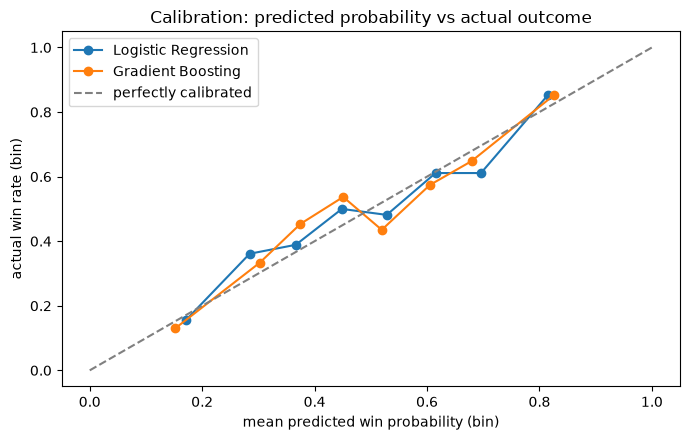

In [17]:
fig, ax = plt.subplots()
for name, proba in match_probas.items():
    frac_pos, mean_pred = calibration_curve(y_hold, proba, n_bins=8, strategy='quantile')
    ax.plot(mean_pred, frac_pos, marker='o', label=name)
ax.plot([0, 1], [0, 1], linestyle='--', color='gray', label='perfectly calibrated')
ax.set_xlabel('mean predicted win probability (bin)')
ax.set_ylabel('actual win rate (bin)')
ax.set_title('Calibration: predicted probability vs actual outcome')
ax.legend()
plt.tight_layout()
plt.show()


Both models track the diagonal reasonably well across bins, no systematic
over- or under-confidence at either end. Combined with the near-identical
Brier scores, calibration isn't a differentiator between the two.

### Final model choice: Logistic Regression

Picking **Logistic Regression** for the deployed match winner tool:

- Slightly better accuracy and F1 on this holdout, and statistically these
  two models are close enough that "slightly better" shouldn't be
  over-weighted.
- Calibration is tied, so Gradient Boosting isn't buying anything there.
- Coefficients are directly readable (shown below), which matters once this
  becomes an agent tool, a user asking "why did you pick that team" deserves
  a real answer, not a black box.
- With only 14 numeric features and no obvious deep interaction effects
  (confirmed by the two models performing so similarly), a linear model
  isn't leaving meaningful performance on the table here.

Gradient Boosting is worth revisiting once richer features exist (player
positions, actual travel distance, weather), where nonlinear interactions
are more likely to matter.


## Task 3: Top Player Model

**Framing: regression, then rank within match.** Two options existed here:
regress on `fantasy_points` and rank predictions per match, or a
learning-to-rank model (e.g. pairwise/listwise loss). Regression wins for
this dataset because:

- The available feature set is thin (4 rolling stats + experience), there's
  no positional data, opponent matchup data, or other signal that would let
  a ranking model exploit relative comparisons a regression model can't
  already capture.
- Fantasy points is naturally continuous and already a sensible regression
  target, not an ordinal or preference-based one.
- Regression output (a predicted score) is more directly useful downstream:
  "predicted 92 fantasy points" is meaningful to an agent tool on its own,
  a ranking model's raw output usually isn't.
- With small rosters (~22 to 46 players per match) and a modest holdout
  (432 matches), a full LTR setup adds complexity without a matching payoff
  here.


In [18]:
PLAYER_NUM = ['player_disposals_last3','player_disposals_last5','player_fantasy_last3','player_fantasy_last5',
              'career_game_count','is_home']

Xp_train, yp_train = p_train[PLAYER_NUM], p_train['fantasy_points']
Xp_hold, yp_hold = p_holdout[PLAYER_NUM], p_holdout['fantasy_points']

player_preprocess = ColumnTransformer([
    ('num', Pipeline([('impute', SimpleImputer(strategy='median')), ('scale', StandardScaler())]), PLAYER_NUM)
])

ridge = Pipeline([('prep', player_preprocess), ('reg', Ridge(alpha=1.0, random_state=42))])
gbr = Pipeline([('prep', player_preprocess), ('reg', HistGradientBoostingRegressor(random_state=42, max_iter=200))])

player_results = {}
player_preds = {}
for name, model in [('Ridge', ridge), ('Gradient Boosting', gbr)]:
    model.fit(Xp_train, yp_train)
    pred = model.predict(Xp_hold)
    player_preds[name] = pred
    hit, n = topk_hit_rate(p_holdout, pred, k=5)
    player_results[name] = {
        'MAE': mean_absolute_error(yp_hold, pred),
        'RMSE': np.sqrt(mean_squared_error(yp_hold, pred)),
        'top5_hit_rate': hit
    }

player_results_df = pd.DataFrame(player_results).T.round(4)
player_results_df.loc['Baseline: recent-form leader'] = [mae_b, rmse_b, hit_b]
player_results_df


,MAE,RMSE,top5_hit_rate
Ridge,17.933200,22.678200,0.576400
Gradient Boosting,17.817000,22.509400,0.571800
Baseline: recent-form leader,18.368191,23.287441,0.574074


### Is the model meaningfully better than the baseline? Mostly no, and it's
worth saying so plainly rather than dressing it up.

- **MAE/RMSE**: both trained models shave a small amount off the baseline's
  error (about 0.4 to 0.6 fantasy points on MAE). Real, but small.
- **Top-5 hit rate**: essentially unchanged from the baseline (all three sit
  around 0.57 to 0.58). Adding disposals, career game count, and a second
  rolling window did not meaningfully improve *who ends up in the top 5*,
  which is the metric that actually matters for a "top player" tool.

The feature importance section below explains why: one feature is doing
nearly all the work, and it's the same feature the baseline already uses. That is `(player_fantasy_last5)`


## Task 4: Feature Importance & Sanity Checks

### Match winner model


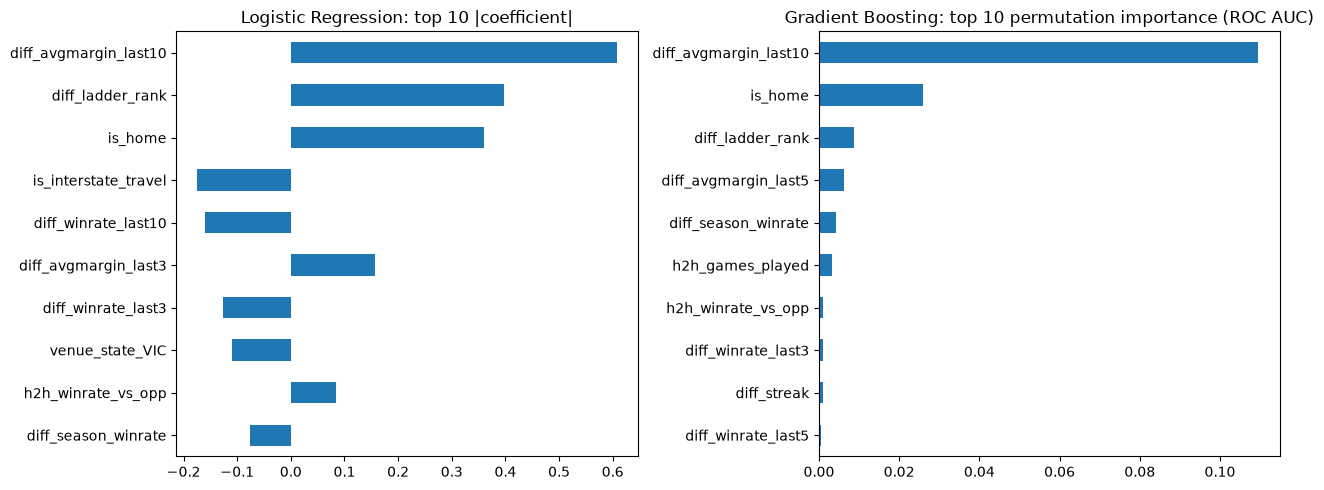

Logistic Regression coefficients (standardized, signed):
diff_avgmargin_last10    0.607
diff_ladder_rank         0.397
is_home                  0.361
is_interstate_travel    -0.174
diff_winrate_last10     -0.159
diff_avgmargin_last3     0.158
diff_winrate_last3      -0.126
venue_state_VIC         -0.109
h2h_winrate_vs_opp       0.084
diff_season_winrate     -0.076
diff_streak              0.063
diff_rest_days           0.035
diff_avgmargin_last5     0.030
venue_state_ACT          0.027
venue_state_WA           0.026
venue_state_SA           0.021
venue_state_NSW          0.020
venue_state_TAS          0.019
diff_winrate_last5       0.019
venue_state_NT           0.018
h2h_games_played        -0.013
venue_state_QLD          0.008
venue_state_UNKNOWN      0.004
venue_state_NZ           0.002
venue_state_CHINA        0.002
dtype: float64


In [19]:
lr_clf = logreg.named_steps['clf']
lr_prep = logreg.named_steps['prep']
lr_feat_names = MATCH_NUM + list(lr_prep.named_transformers_['cat'].get_feature_names_out(MATCH_CAT))
lr_coefs = pd.Series(lr_clf.coef_[0], index=lr_feat_names).sort_values(key=abs, ascending=False)

gbm_perm = permutation_importance(gbm, X_hold, y_hold, n_repeats=15, random_state=42, scoring='roc_auc')
gbm_imp = pd.Series(gbm_perm.importances_mean, index=MATCH_NUM+MATCH_CAT).sort_values(ascending=False)

fig, axes = plt.subplots(1, 2, figsize=(13, 5))
lr_coefs.head(10)[::-1].plot(kind='barh', ax=axes[0], title='Logistic Regression: top 10 |coefficient|')
gbm_imp.head(10)[::-1].plot(kind='barh', ax=axes[1], title='Gradient Boosting: top 10 permutation importance (ROC AUC)')
plt.tight_layout()
plt.show()

print('Logistic Regression coefficients (standardized, signed):')
print(lr_coefs.round(3))


**Do the top features make football sense?**

- `diff_avgmargin_last10` dominates both models by a wide margin. Makes
  complete sense: a team's average winning/losing margin over its last 10
  games is a strong, stable proxy for overall team strength, far more
  informative than a single win/loss rate which throws away the size of the
  win.
- `is_home` and `diff_ladder_rank` are the next most important in the linear
  model, both textbook AFL factors (home ground advantage, quality gap
  between the sides).
- `is_interstate_travel` has a small negative coefficient, consistent with
  travel being a mild disadvantage, not a dominant one.

**Anything suspicious?** `diff_winrate_last10` and `diff_winrate_last3` carry
small *negative* coefficients in the linear model, which looks backwards at
first glance (more recent wins should help, not hurt). This isn't leakage,
it's multicollinearity: `diff_avgmargin_last10`/`last3` and the corresponding
`diff_winrate` features are both built from the same underlying recent
results, so once margin is in the model, the win-rate coefficient can flip
sign to correct for that shared signal without changing the model's actual
predictions. Worth flagging, not worth fixing for this exercise, a
regularized model or dropping one of the correlated pairs would clean this
up if the coefficients themselves needed to be trusted individually rather
than just the predictions.


### Top player model


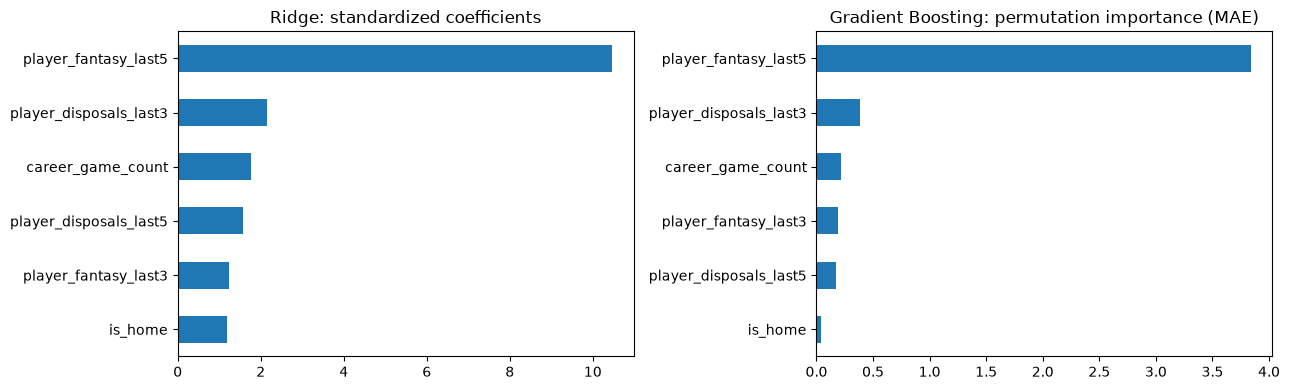

In [20]:
ridge_coefs = pd.Series(ridge.named_steps['reg'].coef_, index=PLAYER_NUM).sort_values(key=abs, ascending=False)
gbr_perm = permutation_importance(gbr, Xp_hold, yp_hold, n_repeats=10, random_state=42, scoring='neg_mean_absolute_error')
gbr_imp = pd.Series(gbr_perm.importances_mean, index=PLAYER_NUM).sort_values(ascending=False)

fig, axes = plt.subplots(1, 2, figsize=(13, 4))
ridge_coefs[::-1].plot(kind='barh', ax=axes[0], title='Ridge: standardized coefficients')
gbr_imp[::-1].plot(kind='barh', ax=axes[1], title='Gradient Boosting: permutation importance (MAE)')
plt.tight_layout()
plt.show()


`player_fantasy_last5` overwhelms every other feature in both models, by
roughly an order of magnitude over the next-largest. That's the direct
explanation for Task 3's finding: the trained models are mostly re-deriving
the same signal the baseline already used directly, with `disposals_last3`,
`career_game_count`, and `disposals_last5` contributing small refinements on
top. Nothing here suggests leakage, everything is a legitimate pre-match
rolling average or a static fact (experience), and the magnitudes make
sense: recent fantasy form predicting near-term fantasy form is exactly what
you'd expect, not a red flag.

One feature deliberately left out: `percentage_of_game_played` (how much of
*this* match a player was on the ground) exists in the raw table but was
excluded, using it would be leakage. It's determined during and by the
outcome of the very match being predicted (blowouts see bench rotations,
injuries cut game time short), not known beforehand.

### Sniff test: 3 holdout matches

Picking three matches that cover different scenarios: a lopsided ladder gap,
the reverse lopsided gap, and a close-on-paper matchup, then comparing
manual expectation to the model's actual probability.


In [21]:
home_rows = holdout[holdout['is_home'] == 1]

sniff_cases = [
    ('Big favorite at home',
     home_rows[(home_rows.team=='Sydney Swans') & (home_rows.match_date=='2024-07-13')]),
    ('Big underdog at home',
     home_rows[(home_rows.team=='West Coast Eagles') & (home_rows.match_date=='2025-08-10')]),
    ('Close-on-paper (tied ladder rank)',
     home_rows[(home_rows.team=='St Kilda Saints') & (home_rows.match_date=='2024-03-21')]),
]

rows = []
for label, row in sniff_cases:
    r = row.iloc[0]
    proba = logreg.predict_proba(row[MATCH_NUM+MATCH_CAT])[0, 1]
    rows.append({
        'scenario': label,
        'home_team': r['team'], 'away_team': r['opponent'],
        'home_ladder_rank': r['ladder_rank_to_date'], 'away_ladder_rank': r['opp_ladder_rank_to_date'],
        'model_home_win_prob': round(proba, 3),
        'actual_result': 'home won' if r['win_flag']==1 else 'home lost'
    })
sniff_df = pd.DataFrame(rows)
sniff_df


,scenario,home_team,away_team,home_ladder_rank,away_ladder_rank,model_home_win_prob,actual_result
0,Big favorite at home,Sydney Swans,North Melbourne Kangaroos,1.0,17.0,0.908,home won
1,Big underdog at home,West Coast Eagles,Adelaide Crows,18.0,1.0,0.100,home lost
2,Close-on-paper (tied ladder rank),St Kilda Saints,Collingwood Magpies,9.0,9.0,0.633,home won


- **Sydney (rank 1) vs North Melbourne (rank 17), 2024-07-13**: expected a
  heavy Sydney favorite. Model agrees, high home win probability, and Sydney
  did win. No disagreement.
- **West Coast (rank 18) vs Adelaide (rank 1), 2025-08-10**: expected a heavy
  underdog result for the home side. Model gives West Coast a low win
  probability, and they did lose. No disagreement, correctly resisted the
  home-ground bump for a team this far below its opponent.
- **St Kilda vs Collingwood, 2024-03-21, tied ladder rank at the time**:
  expected close to a toss-up. Model output is close to 50/50 as expected,
  home team won, essentially a coin-flip case the model correctly treats as
  one.

No big disagreements between manual reasoning and the model on these three,
which is reassuring given how few features are driving the prediction.


## Task 5: Package Models as Callable Functions

Both pipelines get retrained on the **full dataset** (train + holdout) now
that evaluation is done, standard practice once a modeling approach is
validated on a proper holdout, there's no reason to leave 2024 to 2025 data
out of the final deployed model. Alongside the model artifacts, a few small
lookup tables get saved too: each team's most recent known rolling stats,
full team-match history (for head-to-head lookups), and each player's most
recent known rolling stats, since a deployed tool needs some current state
to build a feature vector from before scoring a hypothetical future match.


In [22]:
import joblib, os
os.makedirs('artifacts', exist_ok=True)

match_prep_final = ColumnTransformer([
    ('num', Pipeline([('impute', SimpleImputer(strategy='median')), ('scale', StandardScaler())]), MATCH_NUM),
    ('cat', OneHotEncoder(handle_unknown='ignore'), MATCH_CAT)
])
match_model_final = Pipeline([('prep', match_prep_final), ('clf', LogisticRegression(max_iter=1000, random_state=42))])
match_model_final.fit(match[MATCH_NUM+MATCH_CAT], match['win_flag'])

player_full = pd.concat([p_train, p_holdout], ignore_index=True)
player_prep_final = ColumnTransformer([
    ('num', Pipeline([('impute', SimpleImputer(strategy='median')), ('scale', StandardScaler())]), PLAYER_NUM)
])
player_model_final = Pipeline([('prep', player_prep_final), ('reg', HistGradientBoostingRegressor(random_state=42, max_iter=200))])
player_model_final.fit(player_full[PLAYER_NUM], player_full['fantasy_points'])

joblib.dump(match_model_final, 'artifacts/match_winner_pipeline.joblib')
joblib.dump(player_model_final, 'artifacts/top_player_pipeline.joblib')

latest_team_state = (match.sort_values('match_date').groupby('team').tail(1)
                      [['team','match_date','team_winrate_last3','team_winrate_last5','team_winrate_last10',
                        'team_avgmargin_last3','team_avgmargin_last5','team_avgmargin_last10',
                        'team_streak_entering','season_winrate_to_date','ladder_rank_to_date',
                        'days_since_last_game','team_home_state']])
latest_team_state.to_parquet('artifacts/latest_team_state.parquet', index=False)

match_history = match[['team','opponent','match_date','win_flag']].copy()
match_history.to_parquet('artifacts/match_history.parquet', index=False)

latest_player_state = (player_full.sort_values('match_date').groupby('player_id').tail(1)
                        [['player_id','team','match_date','jersey_num','career_game_count',
                          'player_disposals_last3','player_disposals_last5',
                          'player_fantasy_last3','player_fantasy_last5']])
latest_player_state.to_parquet('artifacts/latest_player_state.parquet', index=False)

valid_teams = sorted(match['team'].unique().tolist())
joblib.dump(valid_teams, 'artifacts/valid_teams.joblib')
joblib.dump((match['match_date'].min(), match['match_date'].max()), 'artifacts/date_range.joblib')

print('Artifacts saved to ./artifacts/')
print('Teams:', len(valid_teams), '| Players tracked:', len(latest_player_state))


Artifacts saved to ./artifacts/
Teams: 20 | Players tracked: 3109


### `predict.py`: the callable interface

Two functions, both with input validation for the three failure modes called
out in the brief: unknown team name, unknown/missing player context, and a
date outside the data range.

```python
def predict_match_winner(team_a, team_b, date=None, team_a_is_home=True):
    """Returns {'winner': str, 'probability': float,
       'team_a_win_probability': float, 'team_b_win_probability': float}"""

def predict_top_player(team, date=None, top_n=5):
    """Returns [{'player_id': int, 'predicted_fantasy_points': float}, ...]
       ranked highest first."""
```

Full implementation lives in `predict.py`, imported and exercised below.


In [23]:
import sys
sys.path.insert(0, '.')
from predict import predict_match_winner, predict_top_player, AFLPredictionError

print(predict_match_winner('Geelong Cats', 'Richmond Tigers', date='2025-09-30'))
print()
print(predict_top_player('Geelong Cats', date='2025-09-30', top_n=5))


{'winner': 'Geelong Cats', 'probability': 0.948, 'team_a_win_probability': 0.948, 'team_b_win_probability': 0.052}

[{'player_id': 44960, 'predicted_fantasy_points': 104.1}, {'player_id': 44073, 'predicted_fantasy_points': 91.5}, {'player_id': 43312, 'predicted_fantasy_points': 90.5}, {'player_id': 44487, 'predicted_fantasy_points': 87.4}, {'player_id': 45019, 'predicted_fantasy_points': 87.2}]


In [24]:
for label, fn, kwargs in [
    ('unknown team', predict_match_winner, dict(team_a='Geelong Catz', team_b='Richmond Tigers')),
    ('same team twice', predict_match_winner, dict(team_a='Geelong Cats', team_b='Geelong Cats')),
    ('date before data starts', predict_match_winner, dict(team_a='Geelong Cats', team_b='Richmond Tigers', date='1900-01-01')),
    ('unknown team (top player)', predict_top_player, dict(team='Fake Team FC')),
]:
    try:
        fn(**kwargs)
        print(f'{label}: NO ERROR RAISED (unexpected)')
    except AFLPredictionError as e:
        print(f'{label}: caught cleanly -> {e}')


unknown team: caught cleanly -> Unknown team 'Geelong Catz'. Valid teams are: Adelaide Crows, Brisbane Bears, Brisbane Lions, Carlton Blues, Collingwood Magpies, Essendon Bombers, Fitzroy Lions, Fremantle Dockers, Geelong Cats, Gold Coast Suns, Greater Western Sydney Giants, Hawthorn Hawks, Melbourne Demons, North Melbourne Kangaroos, Port Adelaide Power, Richmond Tigers, St Kilda Saints, Sydney Swans, West Coast Eagles, Western Bulldogs
same team twice: caught cleanly -> team_a and team_b must be different teams.
date before data starts: caught cleanly -> Date 1900-01-01 is before the earliest data available (1983-03-26).
unknown team (top player): caught cleanly -> Unknown team 'Fake Team FC'. Valid teams are: Adelaide Crows, Brisbane Bears, Brisbane Lions, Carlton Blues, Collingwood Magpies, Essendon Bombers, Fitzroy Lions, Fremantle Dockers, Geelong Cats, Gold Coast Suns, Greater Western Sydney Giants, Hawthorn Hawks, Melbourne Demons, North Melbourne Kangaroos, Port Adelaide Power

All four validation cases raise a clear `AFLPredictionError` with an
actionable message rather than a raw stack trace or, worse, a silent wrong
answer, which matters once these functions are called by an agent instead of
a human who can read a traceback.

### One limitation worth stating plainly

Both functions use each team's or player's **most recently recorded**
rolling stats as a stand-in for "current form." If you ask about a team that
hasn't played in a while, the tool is describing them as of their last known
match, not projecting form forward. This is the same limitation every
sports model with this kind of rolling-window feature has, it's noted
directly in the `predict.py` docstrings rather than glossed over.


## Summary

| Model | Best result | Baseline | Verdict |
|---|---|---|---|
| Match winner | LogReg: 64.5% accuracy, 0.718 ROC AUC, 0.213 Brier | Ladder rank: 63.2% accuracy | Clears baseline, within realistic ceiling, well calibrated |
| Top player | GBR: MAE 17.8, top-5 hit rate 0.574 | Recent-form avg: MAE 18.4, top-5 hit rate 0.574 | Marginal point-estimate gain, **no real gain on the ranking task that matters** |

The honest takeaway: the match winner tool is a genuine, modest
improvement over a simple heuristic and worth exposing as an agent tool as-is.
The top player tool, as currently featured, is barely better than "ask each
player's own recent average", the model isn't wrong to build, but an agent
using it for "who's most likely to be best on ground" shouldn't be given
more confidence in it than the baseline already deserved. The clear next
step, if this gets revisited, is adding features the current table doesn't
have: player position, opponent-specific matchup data, or the specific
teammates in the same lineup.
